# Laser Off Code

In [ ]:
############################ TURN LASER OFF ############################ 
laser.enable(False)
print(f'Laser enable status: {laser.enable()}')

# Set Laser and Powermeters Code

In [ ]:
params.laser_set_standard(laser, wavelength=1550e-9, power=7)
params.laser_get_standard(laser)
params.pmeter_set_standard(pmeter=pm100d, wavelength=1550e-9)
params.pmeter_set_standard(pmeter=pms120, wavelength=1550e-9)

# Import

In [1]:
import time
from time import sleep, monotonic
import datetime
import numpy as np
import matplotlib.pyplot as plt
import sys
import pyvisa
import qcodes as qc
from qcodes.dataset import Measurement
from qcodes.dataset import do0d
from qcodes.dataset.experiment_container import new_experiment, load_experiment_by_name
from qcodes.dataset.plotting import plot_by_id
from qcodes.dataset.data_set import load_by_id, load_by_counter
from qcodes import initialise_or_create_database_at, new_data_set, new_experiment
from qcodes.station import Station
initialise_or_create_database_at("./2026-05-11_SNSPD11.db")
from functions import osc_set_standard, osc_check_standard, capture_trace, capture_trace_simple
from functions import snspd_dark_counts
from functions import snspd_counts_vs_wavelength
from functions import laser_set_standard, laser_get_standard
from functions import snspd_counts_vs_current
import snspd
params = snspd.snspd('snspd11.yaml')

# Set up experiment
exp_name = 'SNSPD11_11_05_2026'
sample_name = '00'

try:
    exp = qc.load_experiment_by_name(exp_name, sample=sample_name)
    print('Experiment loaded. Last ID no:', exp.last_counter)
except ValueError:
    exp = new_experiment(exp_name, sample_name)
    print('Started new experiment')

Logging hadn't been started.
Activating auto-logging. Current session state plus future input saved.
Filename       : C:\Users\QNL\.qcodes\logs\command_history.log
Mode           : append
Output logging : True
Raw input log  : False
Timestamping   : True
State          : active
Qcodes Logfile : C:\Users\QNL\.qcodes\logs\260512-28656-qcodes.log
Experiment loaded. Last ID no: 18


In [16]:
import functions
import importlib
importlib.reload(functions)
from functions import osc_set_standard, osc_check_standard, capture_trace, capture_trace_simple
from functions import snspd_dark_counts
from functions import snspd_counts_vs_wavelength
from functions import laser_set_standard, laser_get_standard

In [2]:
import importlib
importlib.reload(snspd)
params = snspd.snspd('snspd11.yaml')

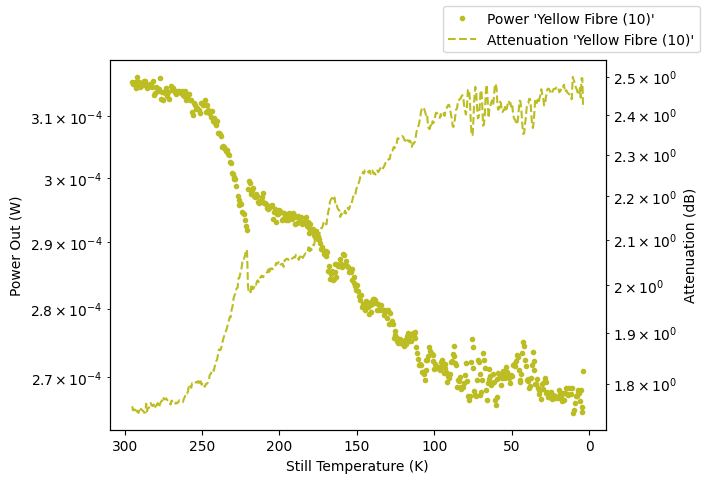

In [6]:
db10 = "./2026-04-17_SNSPD10.db"
exname10 = 'SNSPD10'
sampname10 = '00'
ID = 7
data_10 = params.load_id_from_database(db10, exname10, sampname10, ID).get_parameter_data()
power10_10 = data_10['power10']['power10']
power90_10 = data_10['power90']['power90']
attenuation_10 = data_10['attenuation']['attenuation']
still_temp_10 = data_10['still_temp']['still_temp']

fig, ax1 = plt.subplots()

ax2 = ax1.twinx()

ax1.semilogy(still_temp_10, power10_10, '.', color = 'tab:olive', label='Power \'Yellow Fibre (10)\'')
ax1.set_xlabel('Still Temperature (K)')
ax1.set_ylabel('Power Out (W)')
ax1.invert_xaxis()

ax2.semilogy(still_temp_10, attenuation_10, '--', color='tab:olive', label='Attenuation \'Yellow Fibre (10)\'') 
ax2.set_xlabel('Still Temperature (K)')
ax2.set_ylabel('Attenuation (dB)')

fig.legend()


In [7]:
min(still_temp_10)

np.float64(3.894396)

# Instruments

In [4]:
station = Station(config_file="friesland.yaml")
dmm = station.load_instrument("dmm", revive_instance=True)
yoko = station.load_instrument("yoko", revive_instance=True)
laser = station.load_instrument("laser", revive_instance=True)
MS = station.load_instrument("mso5", revive_instance=True)
# pm100usb = station.load_instrument("pm100usb", revive_instance=True)
pm100d = station.load_instrument("pm100d", revive_instance=True) 
pms120 = station.load_instrument("pms120", revive_instance=True)
tc = station.load_instrument("fridge", revive_instance=True)
p_att = station.load_instrument("dmm_keithley", revive_instance=True) # excluding from snapshot because none of the parameters work anyway

Connected to: Thorlabs PM100D (serial:P0033329, firmware:2.8.1) in 5.54s


2026-05-12 11:13:25,570 ¦ qcodes.instrument.instrument_base ¦ WARNING ¦ instrument_base ¦ snapshot_base ¦ 464 ¦ [pm100d(Thorlabs_PM100D)] Snapshot: Could not update parameter: beam_diameter
2026-05-12 11:13:25,735 ¦ py.warnings ¦ WARNING ¦ warnings ¦ _showwarnmsg ¦ 110 ¦ C:\Users\QNL\anaconda3\envs\qcodes\Lib\site-packages\pyvisa\resources\messagebased.py:702: UserWarning: read string doesn't end with termination characters
  return self.read()



Connected to: Keithley instruments 2230G-30-1 (serial:9010428, firmware:1.16-1.04) in 0.14s


In [10]:
params.h_time_counts

'100e-3'

In [11]:
params.v_scale_counts

'150e-3'

In [12]:
# Set oscilloscope vertical and horizontal parameters 
osc_set_standard(MS, v_scale=params.v_scale_counts, h_time=100e-3, h_pos=params.h_pos_counts)
osc_check_standard(MS)

MANUAL
RECORDLENGTH
625000000.0
10.0
0.01
0.0
0.15
50.0
1000000000.0
0.0
0.0
0.0
1.0
0
0.0


In [15]:
############################ TURN LASER ON ############################ 
laser.enable(True)
print(f'Laser enable status: {laser.enable()}')

Laser enable status: True


In [16]:
############################ TURN LASER OFF ############################ 
laser.enable(False)
print(f'Laser enable status: {laser.enable()}')

Laser enable status: False


In [17]:
params.laser_get_standard(laser)

Power: 7.0
Frequency coarse: 193.4144THz
Wavelength (calculated) is 1550.000713493928nm


In [19]:
############################ TURN LASER ON ############################ 
laser.enable(True)
print(f'Laser enable status: {laser.enable()}')

Laser enable status: True


In [20]:
pms120.power()

2026-05-11 14:15:08,455 ¦ py.warnings ¦ WARNING ¦ warnings ¦ _showwarnmsg ¦ 110 ¦ C:\Users\QNL\anaconda3\envs\qcodes\Lib\site-packages\pyvisa\resources\messagebased.py:702: UserWarning: read string doesn't end with termination characters
  return self.read()



0.00488183135

In [22]:
############################ TURN LASER OFF ############################ 
laser.enable(False)
print(f'Laser enable status: {laser.enable()}')

Laser enable status: False


In [23]:
############################ TURN LASER ON ############################ 
laser.enable(True)
print(f'Laser enable status: {laser.enable()}')
time.sleep(10)

Laser enable status: True


In [29]:
############################ TURN LASER OFF ############################ 
laser.enable(False)
print(f'Laser enable status: {laser.enable()}')

Laser enable status: False


In [3]:
laser.enable()

False

In [27]:
# Set oscilloscope vertical and horizontal parameters 
osc_set_standard(MS, v_scale=params.v_scale_counts, h_time=100e-3, h_pos=params.h_pos_counts)
osc_check_standard(MS)

MANUAL
RECORDLENGTH
625000000.0
10.0
0.01
0.0
0.15
50.0
1000000000.0
0.0
0.0
0.0
1.0
0
0.0


In [26]:
############################ TURN LASER ON ############################ 
laser.enable(True)
print(f'Laser enable status: {laser.enable()}')
time.sleep(10)

Laser enable status: True


In [5]:
pm100d.wavelength()

1.55e-06

In [6]:
pms120.wavelength()


2026-05-12 11:13:58,574 ¦ py.warnings ¦ WARNING ¦ warnings ¦ _showwarnmsg ¦ 110 ¦ C:\Users\QNL\anaconda3\envs\qcodes\Lib\site-packages\pyvisa\resources\messagebased.py:702: UserWarning: read string doesn't end with termination characters
  return self.read()



1550.0

In [5]:
params.quick_check(pmeter10=pm)

2026-05-11 16:31:08,642 ¦ qcodes.dataset.measurements ¦ WARNING ¦ measurements ¦ __exit__ ¦ 758 ¦ An exception occurred in measurement with guid: def62fa7-0000-0000-0000-019e15bb78f3;
Traceback:
Traceback (most recent call last):
  File "D:\SNSPD\SNSPD2\snspd.py", line 87, in quick_check
    power10 = self.pmeter10.power()
              ^^^^^^^^^^^^^^^^^^^
AttributeError: 'str' object has no attribute 'power'. Did you mean: 'lower'?



Starting experimental run with id: 2. 
2


AttributeError: 'str' object has no attribute 'power'

In [3]:
station = Station(config_file="friesland.yaml")
pm100d = station.load_instrument("pm100d", revive_instance=True) 
pms120 = station.load_instrument("pms120", revive_instance=True)
laser = station.load_instrument("laser", revive_instance=True)

Connected to: Thorlabs PM100D (serial:P0033329, firmware:2.8.1) in 5.53s


2026-05-12 11:42:37,720 ¦ qcodes.instrument.instrument_base ¦ WARNING ¦ instrument_base ¦ snapshot_base ¦ 464 ¦ [pm100d(Thorlabs_PM100D)] Snapshot: Could not update parameter: beam_diameter
2026-05-12 11:42:38,892 ¦ qcodes.instrument.instrument_base ¦ WARNING ¦ instrument ¦ get_idn ¦ 113 ¦ [pms120(Thorlabs_S120)] Error getting or interpreting *IDN?: ''
Traceback (most recent call last):
  File "C:\Users\QNL\anaconda3\envs\qcodes\Lib\site-packages\qcodes\instrument\instrument.py", line 100, in get_idn
    idstr = self.ask("*IDN?")
  File "C:\Users\QNL\anaconda3\envs\qcodes\Lib\site-packages\qcodes\instrument\instrument.py", line 445, in ask
    raise e
  File "C:\Users\QNL\anaconda3\envs\qcodes\Lib\site-packages\qcodes\instrument\instrument.py", line 439, in ask
    answer = self.ask_raw(cmd)
  File "C:\Users\QNL\anaconda3\envs\qcodes\Lib\site-packages\qcodes\instrument\visa.py", line 394, in ask_raw
    response = self.visa_handle.query(cmd)
  File "C:\Users\QNL\anaconda3\envs\qcodes\L

Connected to: PurePhotonic PPCL550 (serial:PP70AJ005, firmware:PV 2.0.0:HW 3.0.0:FW 7.0.0:AS C1:OT 1.0.0) in 1.56s


In [4]:
pm100d.wavelength(), pms120.wavelength()

(1.55e-06, 1.55e-06)

In [6]:
pms120.wavelength(1550e-9)

In [7]:
pms120.wavelength()

1.55e-06

In [7]:
params.laser_set_standard(laser, wavelength=1550e-9, power=7)
params.laser_get_standard(laser)
params.pmeter_set_standard(pmeter=pm100d, wavelength=1550e-9)
params.pmeter_set_standard(pmeter=pms120, wavelength=1550e-9)

Power: 7.0
Frequency coarse: 193.4144THz
Wavelength (calculated) is 1550.000713493928nm


In [9]:
params.pmeter_set_standard(pmeter=pm100d, wavelength=1550e-9)

Powermeter wavelength is 1.55e-06


In [11]:
params.pmeter_set_standard(pmeter=pms120, wavelength=1550e-9)

2026-05-12 11:36:56,205 ¦ py.warnings ¦ WARNING ¦ warnings ¦ _showwarnmsg ¦ 110 ¦ C:\Users\QNL\anaconda3\envs\qcodes\Lib\site-packages\pyvisa\resources\messagebased.py:702: UserWarning: read string doesn't end with termination characters
  return self.read()



Powermeter wavelength is 1.55e-06


In [14]:
params.quick_check(pmeter10=pm100d, pmeter90=pms120, attenuator_name='')

Starting experimental run with id: 7. 
7


2026-05-12 12:40:52,892 ¦ py.warnings ¦ WARNING ¦ warnings ¦ _showwarnmsg ¦ 110 ¦ C:\Users\QNL\anaconda3\envs\qcodes\Lib\site-packages\pyvisa\resources\messagebased.py:702: UserWarning: read string doesn't end with termination characters
  return self.read()



Could not calculate attenuation, missing beam splitter values
power10: 1.67459457e-09, power90: 2.28189112e-09


In [11]:
def beam_splitter_calc(power10, power90): 
    bs10 = power10/(power10+power90)
    bs90 = power90/(power10+power90)
    return bs10, bs90

In [ ]:
bs10, bs90 = beam_splitter_calc(power10, power90)

In [ ]:
params.quick_check(pmeter10=pm100d, pmeter90=pms120, attenuator=')

In [15]:
############################ TURN LASER OFF ############################ 
laser.enable(False)
print(f'Laser enable status: {laser.enable()}')

Laser enable status: False


# Light Counts vs Current

In [17]:
# Take same current range as ID 12
ID = 12
data = load_by_id(ID).get_parameter_data()
print(data['yoko_current']['yoko_current'])

[6.000e-06 6.250e-06 6.500e-06 6.750e-06 7.000e-06 7.250e-06 7.500e-06
 7.750e-06 8.000e-06 8.250e-06 8.500e-06 8.750e-06 9.000e-06 9.250e-06
 9.500e-06 9.750e-06 1.000e-05 1.025e-05 1.050e-05 1.075e-05 1.100e-05
 1.125e-05 1.150e-05 1.175e-05 1.200e-05 1.225e-05 1.250e-05 1.275e-05
 1.300e-05 1.325e-05 1.350e-05 1.375e-05 1.400e-05 1.425e-05]


In [18]:
np.arange(6e-6, 14.5e-6, 0.25e-6)

array([6.000e-06, 6.250e-06, 6.500e-06, 6.750e-06, 7.000e-06, 7.250e-06,
       7.500e-06, 7.750e-06, 8.000e-06, 8.250e-06, 8.500e-06, 8.750e-06,
       9.000e-06, 9.250e-06, 9.500e-06, 9.750e-06, 1.000e-05, 1.025e-05,
       1.050e-05, 1.075e-05, 1.100e-05, 1.125e-05, 1.150e-05, 1.175e-05,
       1.200e-05, 1.225e-05, 1.250e-05, 1.275e-05, 1.300e-05, 1.325e-05,
       1.350e-05, 1.375e-05, 1.400e-05, 1.425e-05])

In [20]:
print(params.v_scale_counts)
print(params.h_time_counts)
print(params.h_pos_counts)

currents = np.arange(6e-6, 14.5e-6, 0.25e-6)

# Set oscilloscope vertical and horizontal parameters 
osc_set_standard(MS, v_scale=params.v_scale_counts, h_time=params.h_time_counts, h_pos=params.h_pos_counts)
osc_check_standard(MS)

if MS.channels[0].clipping(): 
    print('Error: Clipping')

# Set attenuator voltage
v_attenuator = 5.3 # from SNSPD4_3_Calibration.ipynb 
p_att.write(f'VOLT {v_attenuator}')

# Set standard laser parameters 
laser_set_standard(laser, 1550e-9, 7)
laser_get_standard(laser)

# Set to start current 
yoko.current(currents[0])

############################ TURN LASER ON ############################ 
laser.enable(True)
time.sleep(10)
print(f'Laser enable status: {laser.enable()}')


snspd_counts_vs_current(MS, dmm, yoko, p_att, device_name=params.device_1_name, n_captures=10, interval=1, currents=currents, station=station)



############################ TURN LASER OFF ############################ 
laser.enable(False)
print(f'Laser enable status: {laser.enable()}')

0.15
0.1
0
MANUAL
RECORDLENGTH
625000000.0
10.0
0.01
0.0
0.15
50.0
1000000000.0
0.0
0.0
0.0
1.0
0
0.0
Power: 7.0
Frequency coarse: 193.4144THz
Wavelength (calculated) is 1550.000713493928nm
Laser enable status: True
update station
Ramping current from 6e-06A to 6e-06A
Starting experimental run with id: 475. 
475
Starting current 6e-06
This acquisition will take 10s
14 43
Starting current 6.25e-06
This acquisition will take 10s
14 44
Starting current 6.5e-06
This acquisition will take 10s
14 44
Starting current 6.75e-06
This acquisition will take 10s
14 44
Starting current 7e-06
This acquisition will take 10s
14 44
Starting current 7.25e-06
This acquisition will take 10s
14 45
Starting current 7.5e-06
This acquisition will take 10s
14 45
Starting current 7.75e-06
This acquisition will take 10s
14 45
Starting current 8e-06
This acquisition will take 10s
14 45
Starting current 8.25e-06
This acquisition will take 10s
14 46
Starting current 8.5e-06
This acquisition will take 10s
14 46
Start